# SayurKita — Notebook 4: Indonesian Food Nutrition




---
##  0. Import Libraries


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
import json
import os

warnings.filterwarnings('ignore')
%matplotlib inline

# Konsistensi style grafik
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

print(" Library berhasil di-import!")
print(f"   pandas  : {pd.__version__}")
print(f"   numpy   : {np.__version__}")

 Library berhasil di-import!
   pandas  : 2.2.2
   numpy   : 2.0.2


---
##  1. Data Loading & Initial Inspection



In [ ]:
# --- Load Dataset ---
NUTRITION_PATH = '/content/nutrition.csv'

df_nutrition = pd.read_csv(NUTRITION_PATH)

print(f" Dataset berhasil di-load!")
print(f"   Jumlah baris  : {df_nutrition.shape[0]:,}")
print(f"   Jumlah kolom  : {df_nutrition.shape[1]}")
print(f"   Kolom         : {list(df_nutrition.columns)}")

 Dataset berhasil di-load!
   Jumlah baris  : 1,346
   Jumlah kolom  : 7
   Kolom         : ['id', 'calories', 'proteins', 'fat', 'carbohydrate', 'name', 'image']


In [ ]:
# --- Lihat 5 baris pertama ---
print("5 Data Teratas:")
df_nutrition.head()

5 Data Teratas:


,id,calories,proteins,fat,carbohydrate,name,image
0,1,280.0,9.2,28.4,0.0,Abon,https://img-cdn.medkomtek.com/PbrY9X3ignQ8sVuj...
1,2,513.0,23.7,37.0,21.3,Abon haruwan,https://img-global.cpcdn.com/recipes/cbf330fbd...
2,3,0.0,0.0,0.2,0.0,Agar-agar,https://res.cloudinary.com/dk0z4ums3/image/upl...
3,4,45.0,1.1,0.4,10.8,Akar tonjong segar,https://images.tokopedia.net/img/cache/200-squ...
4,5,37.0,4.4,0.5,3.8,Aletoge segar,https://nilaigizi.com/assets/images/produk/pro...


In [ ]:
# --- Cek tipe data dan missing values ---
print(" Info Dataset:")
print("-" * 50)
df_nutrition.info()

print("\n Statistik Deskriptif Kolom Numerik:")
print("-" * 50)
df_nutrition.describe().round(2)

 Info Dataset:
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1346 entries, 0 to 1345
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            1346 non-null   int64  
 1   calories      1346 non-null   float64
 2   proteins      1346 non-null   float64
 3   fat           1346 non-null   float64
 4   carbohydrate  1346 non-null   float64
 5   name          1346 non-null   object 
 6   image         1346 non-null   object 
dtypes: float64(4), int64(1), object(2)
memory usage: 73.7+ KB

 Statistik Deskriptif Kolom Numerik:
--------------------------------------------------


,id,calories,proteins,fat,carbohydrate
count,1346.00,1346.00,1346.00,1346.00,1346.00
mean,673.50,203.22,10.00,7.58,25.39
std,388.70,163.08,11.85,13.73,32.19
min,1.00,0.00,0.00,0.00,0.00
25%,337.25,75.00,1.80,0.50,4.53
50%,673.50,146.00,5.00,2.00,13.30
75%,1009.75,333.75,15.00,8.28,37.58
max,1346.00,940.00,83.00,100.00,647.00


In [ ]:
# --- Ringkasan Missing Values ---
missing = df_nutrition.isnull().sum()
missing_pct = (missing / len(df_nutrition) * 100).round(2)

missing_report = pd.DataFrame({
    'Jumlah Missing': missing,
    'Persentase (%)': missing_pct
})

print("  Laporan Missing Values:")
print("-" * 40)
print(missing_report.to_string())

total_valid = len(df_nutrition) - missing['name']
print(f"\n Catatan: {total_valid:,} baris memiliki data lengkap dari total {len(df_nutrition):,} baris.")

  Laporan Missing Values:
----------------------------------------
              Jumlah Missing  Persentase (%)
id                         0             0.0
calories                   0             0.0
proteins                   0             0.0
fat                        0             0.0
carbohydrate               0             0.0
name                       0             0.0
image                      0             0.0

 Catatan: 1,346 baris memiliki data lengkap dari total 1,346 baris.


---
##  2. Exploratory Data Analysis (EDA)

 Dua hal yang paling relevan untuk SayurKita:
1. Distribusi kalori — seberapa variatif energi dari 1.300+ makanan ini?
2. Top 10 bahan berprotein tinggi — berguna untuk fitur 'Nutrition Rescue Card'.

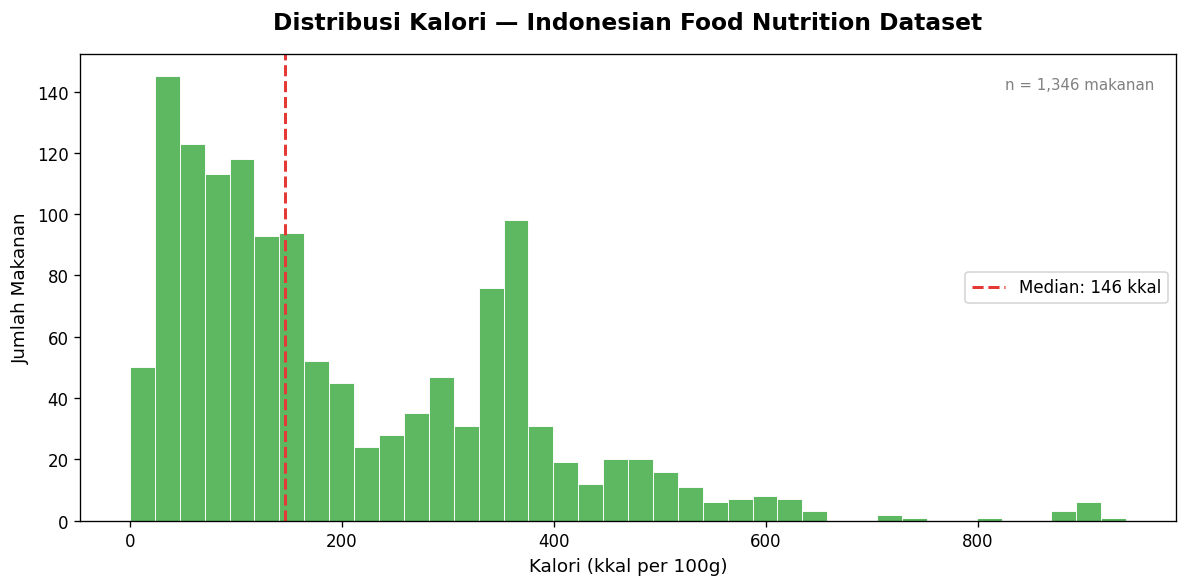


 Insight:
   - Rata-rata kalori : 203.2 kkal/100g
   - Median kalori    : 146.0 kkal/100g
   - Kalori tertinggi : 940 kkal/100g
   - Kalori terendah  : 0 kkal/100g


In [ ]:
# --- EDA 1: Distribusi Kalori ---
df_cal = df_nutrition['calories'].dropna()
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df_cal, bins=40, color='#4CAF50', edgecolor='white', linewidth=0.6, alpha=0.9)

# Tambah garis median
median_cal = df_cal.median()
ax.axvline(median_cal, color='#E53935', linestyle='--', linewidth=1.8,
           label=f'Median: {median_cal:.0f} kkal')

ax.set_title('Distribusi Kalori — Indonesian Food Nutrition Dataset',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Kalori (kkal per 100g)', fontsize=11)
ax.set_ylabel('Jumlah Makanan', fontsize=11)
ax.legend(fontsize=10)
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))

# Tambah anotasi singkat
ax.text(0.98, 0.95, f'n = {len(df_cal):,} makanan',
        transform=ax.transAxes, ha='right', va='top',
        fontsize=9, color='gray')

plt.tight_layout()
plt.savefig('eda_distribusi_kalori.png', bbox_inches='tight')  # simpan untuk dokumentasi
plt.show()

print(f"\n Insight:")
print(f"   - Rata-rata kalori : {df_cal.mean():.1f} kkal/100g")
print(f"   - Median kalori    : {df_cal.median():.1f} kkal/100g")
print(f"   - Kalori tertinggi : {df_cal.max():.0f} kkal/100g")
print(f"   - Kalori terendah  : {df_cal.min():.0f} kkal/100g")

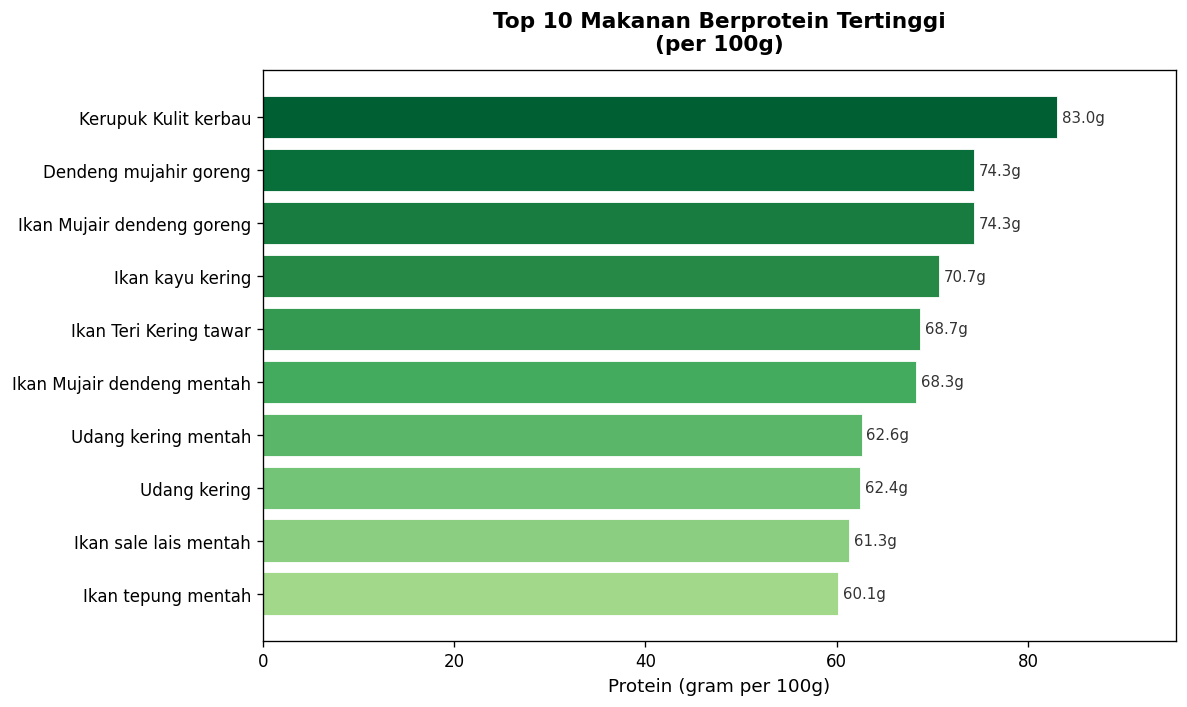


 Tabel Top 10 Protein Tertinggi:
----------------------------------------
                      name  proteins
      Kerupuk Kulit kerbau      83.0
    Dendeng mujahir goreng      74.3
Ikan Mujair dendeng goreng      74.3
          Ikan kayu kering      70.7
    Ikan Teri Kering tawar      68.7
Ikan Mujair dendeng mentah      68.3
       Udang kering mentah      62.6
              Udang kering      62.4
     Ikan sale lais mentah      61.3
        Ikan tepung mentah      60.1


In [ ]:
# --- EDA 2: Top 10 Bahan dengan Protein Tertinggi ---

# Hapus baris yang protein atau nama-nya kosong dulu
df_protein = df_nutrition[['name', 'proteins']].dropna()

# Ambil top 10 tertinggi
top10_protein = df_protein.nlargest(10, 'proteins').reset_index(drop=True)
fig, ax = plt.subplots(figsize=(10, 6))

# Horizontal bar chart
colors = plt.cm.YlGn(np.linspace(0.4, 0.9, 10))[::-1]
bars = ax.barh(top10_protein['name'], top10_protein['proteins'],
               color=colors, edgecolor='white', linewidth=0.5)

# Tambah label nilai di ujung tiap bar
for bar, val in zip(bars, top10_protein['proteins']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}g', va='center', fontsize=9, color='#333')

ax.set_title('Top 10 Makanan Berprotein Tertinggi\n(per 100g)',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Protein (gram per 100g)', fontsize=11)
ax.invert_yaxis()  # urutan 1 di atas
ax.set_xlim(0, top10_protein['proteins'].max() * 1.15)

plt.tight_layout()
plt.savefig('eda_top10_protein.png', bbox_inches='tight')
plt.show()

print("\n Tabel Top 10 Protein Tertinggi:")
print("-" * 40)
print(top10_protein.to_string(index=False))

---
##  3. Data Cleaning & Restructuring

**Langkah-langkah:**
1. Normalisasi kolom `name` → lowercase + strip spasi
2. Rename kolom agar sinkron dengan schema database SayurKita
3. Pilih hanya 5 kolom yang dibutuhkan
4. Hapus duplikat berdasarkan `nama_bersih`

In [ ]:
# --- Step 3.1: Copy dataframe
df_clean = df_nutrition.copy()
print(f" Copy dataframe berhasil. Shape: {df_clean.shape}")

 Copy dataframe berhasil. Shape: (1346, 7)


In [ ]:
# --- Step 3.2: Hapus baris dengan nilai kritis yang kosong ---
sebelum = len(df_clean)
df_clean = df_clean.dropna(subset=['name'])
sesudah = len(df_clean)

print(f"  Hapus baris tanpa nama: {sebelum - sesudah} baris dihapus")
print(f"   Sisa: {sesudah:,} baris")

  Hapus baris tanpa nama: 0 baris dihapus
   Sisa: 1,346 baris


In [ ]:
# --- Step 3.3: Normalisasi kolom 'name' ---
df_clean['name'] = df_clean['name'].str.lower().str.strip()

print(" Normalisasi selesai. Contoh hasil:")
print(df_clean['name'].head(10).to_string())

 Normalisasi selesai. Contoh hasil:
0                  abon
1          abon haruwan
2             agar-agar
3    akar tonjong segar
4         aletoge segar
5         alpukat segar
6    ampas kacang hijau
7            ampas tahu
8      ampas tahu kukus
9     ampas tahu mentah


In [ ]:
# --- Step 3.4: Rename kolom sesuai schema SayurKita ---

rename_map = {
    'name'        : 'nama_bersih',
    'calories'    : 'kalori_per_100g',
    'proteins'    : 'protein_g',
    'fat'         : 'lemak_g',
    'carbohydrate': 'karbo_g'
}

df_clean = df_clean.rename(columns=rename_map)

print(" Kolom berhasil di-rename:")
for old, new in rename_map.items():
    print(f"   '{old}' → '{new}'")

 Kolom berhasil di-rename:
   'name' → 'nama_bersih'
   'calories' → 'kalori_per_100g'
   'proteins' → 'protein_g'
   'fat' → 'lemak_g'
   'carbohydrate' → 'karbo_g'


In [ ]:
# --- Step 3.5: Seleksi hanya 5 kolom yang dibutuhkan ---

KOLOM_YANG_DIPAKAI = ['nama_bersih', 'kalori_per_100g', 'protein_g', 'lemak_g', 'karbo_g']
df_clean = df_clean[KOLOM_YANG_DIPAKAI]

print(f" Seleksi kolom selesai. Kolom yang tersisa: {list(df_clean.columns)}")
print(f"   Shape setelah seleksi: {df_clean.shape}")

 Seleksi kolom selesai. Kolom yang tersisa: ['nama_bersih', 'kalori_per_100g', 'protein_g', 'lemak_g', 'karbo_g']
   Shape setelah seleksi: (1346, 5)


In [ ]:
# --- Step 3.6: Hapus duplikat berdasarkan 'nama_bersih' ---

sebelum_dedup = len(df_clean)
df_clean = df_clean.drop_duplicates(subset='nama_bersih', keep='first').reset_index(drop=True)
sesudah_dedup = len(df_clean)

print(f" Deduplikasi berdasarkan 'nama_bersih':")
print(f"   Sebelum : {sebelum_dedup:,} baris")
print(f"   Dihapus : {sebelum_dedup - sesudah_dedup} duplikat")
print(f"   Sesudah : {sesudah_dedup:,} baris unik")

 Deduplikasi berdasarkan 'nama_bersih':
   Sebelum : 1,346 baris
   Dihapus : 3 duplikat
   Sesudah : 1,343 baris unik


In [ ]:
# --- Ringkasan akhir proses cleaning ---
print("=" * 50)
print(" RINGKASAN CLEANING SELESAI")
print("=" * 50)
print(f"  Baris awal         : {len(df_nutrition):,}")
print(f"  Baris final bersih : {len(df_clean):,}")
print(f"  Kolom              : {list(df_clean.columns)}")
print()
print("Contoh 5 data bersih:")
df_clean.head()

 RINGKASAN CLEANING SELESAI
  Baris awal         : 1,346
  Baris final bersih : 1,343
  Kolom              : ['nama_bersih', 'kalori_per_100g', 'protein_g', 'lemak_g', 'karbo_g']

Contoh 5 data bersih:


,nama_bersih,kalori_per_100g,protein_g,lemak_g,karbo_g
0,abon,280.0,9.2,28.4,0.0
1,abon haruwan,513.0,23.7,37.0,21.3
2,agar-agar,0.0,0.0,0.2,0.0
3,akar tonjong segar,45.0,1.1,0.4,10.8
4,aletoge segar,37.0,4.4,0.5,3.8


---
##  4. Export Nutrition yang Sudah Bersih



In [ ]:
# --- Export nutrition_cleaned.csv ---
OUTPUT_NUTRITION = 'nutrition_cleaned.csv'
df_clean.to_csv(OUTPUT_NUTRITION, index=False, encoding='utf-8')

print(f" File berhasil disimpan: '{OUTPUT_NUTRITION}'")
print(f"   Ukuran file: {os.path.getsize(OUTPUT_NUTRITION) / 1024:.1f} KB")
print(f"   Total baris (tidak termasuk header): {len(df_clean):,}")

 File berhasil disimpan: 'nutrition_cleaned.csv'
   Ukuran file: 46.8 KB
   Total baris (tidak termasuk header): 1,343
